In [27]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Churn_Modelling.csv")

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [7]:
df.Exited.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [8]:
df.Geography.value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [10]:
df.drop(columns = ["RowNumber" , "CustomerId" , "Surname"] , inplace = True)

In [11]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
df = pd.get_dummies(df, columns = ["Geography" , "Gender"] , drop_first = True)

In [14]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [15]:
x= df.drop(columns = ["Exited"])
y = df.Exited
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = .2 , random_state = 1)

In [16]:
x_train.shape

(8000, 11)

In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [30]:
x_train_scaled[1]

array([-0.25150912, -0.94449979, -0.35520275,  0.46984886,  0.80225696,
       -1.55337352, -1.02327069, -1.02548708, -0.58312392, -0.57273139,
       -1.09278791])

In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [47]:
model = Sequential()

model.add(Dense(11 , activation = "relu" , input_dim = 11))
model.add(Dense(11 , activation = "relu"))
model.add(Dense(1 , activation = "sigmoid"))

In [48]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 11)                132       
                                                                 
 dense_5 (Dense)             (None, 11)                132       
                                                                 
 dense_6 (Dense)             (None, 1)                 12        
                                                                 
Total params: 276 (1.08 KB)
Trainable params: 276 (1.08 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [49]:
model.compile(loss = "binary_crossentropy" , optimizer = "adam", metrics = "accuracy")

In [61]:
history = model.fit(x_train_scaled , y_train , epochs=100 , validation_split = 0.2)

Epoch 1/35
200/200 [==============================] - 0s 2ms/step - loss: 0.3155 - accuracy: 0.8667 - val_loss: 0.3413 - val_accuracy: 0.8619
Epoch 2/35
200/200 [==============================] - 0s 1ms/step - loss: 0.3156 - accuracy: 0.8681 - val_loss: 0.3388 - val_accuracy: 0.8587
Epoch 3/35
200/200 [==============================] - 0s 1ms/step - loss: 0.3161 - accuracy: 0.8691 - val_loss: 0.3383 - val_accuracy: 0.8600
Epoch 4/35
200/200 [==============================] - 0s 1ms/step - loss: 0.3155 - accuracy: 0.8670 - val_loss: 0.3385 - val_accuracy: 0.8587
Epoch 5/35
200/200 [==============================] - 0s 1ms/step - loss: 0.3156 - accuracy: 0.8680 - val_loss: 0.3399 - val_accuracy: 0.8594
Epoch 6/35
200/200 [==============================] - 0s 1ms/step - loss: 0.3151 - accuracy: 0.8691 - val_loss: 0.3425 - val_accuracy: 0.8612
Epoch 7/35
200/200 [==============================] - 0s 1ms/step - loss: 0.3161 - accuracy: 0.8681 - val_loss: 0.3424 - val_accuracy: 0.8625
Epoch 

In [62]:
history.history

{'loss': [0.31547680497169495,
  0.31555473804473877,
  0.31607380509376526,
  0.3155444264411926,
  0.3156481981277466,
  0.3151319622993469,
  0.31606122851371765,
  0.31550130248069763,
  0.3149358630180359,
  0.3148045241832733,
  0.3149716854095459,
  0.3147464692592621,
  0.3154527544975281,
  0.3151484727859497,
  0.31475621461868286,
  0.31480395793914795,
  0.31472426652908325,
  0.3146858513355255,
  0.31462639570236206,
  0.31565287709236145,
  0.3145659863948822,
  0.3148837983608246,
  0.31398192048072815,
  0.313547283411026,
  0.31426727771759033,
  0.31500348448753357,
  0.31401917338371277,
  0.3141646087169647,
  0.3138209581375122,
  0.31432676315307617,
  0.3144626319408417,
  0.3137367069721222,
  0.3137981593608856,
  0.3135150969028473,
  0.3136492073535919],
 'accuracy': [0.8667187690734863,
  0.8681250214576721,
  0.8690624833106995,
  0.8670312762260437,
  0.867968738079071,
  0.8690624833106995,
  0.8681250214576721,
  0.8675000071525574,
  0.8684375286102295

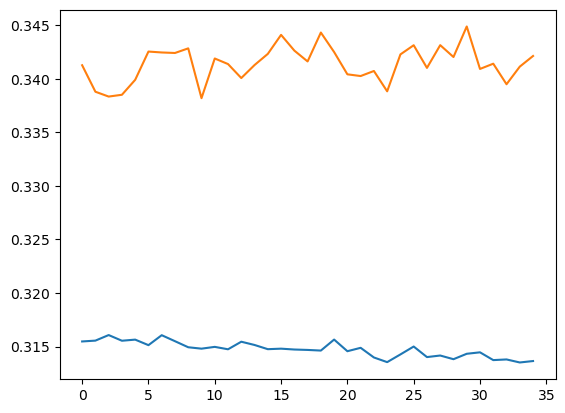

In [63]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])



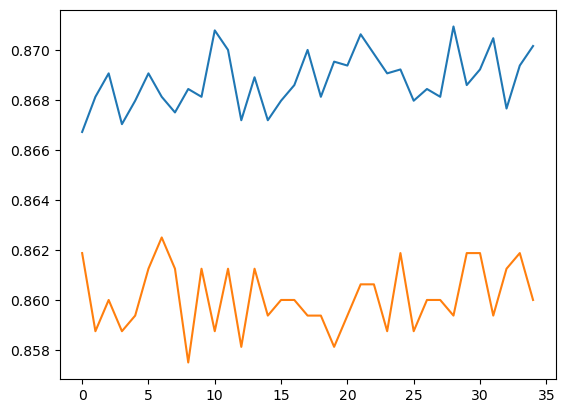

In [64]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

In [65]:
model.layers[0].get_weights()

[array([[ 0.01404387,  0.1328701 , -0.00594182, -0.04243097,  0.09504632,
         -0.1323138 ,  0.09427629,  0.5212125 , -0.01575597,  0.07777371,
          0.2771427 ],
        [ 0.72794324,  1.1627237 , -0.2831461 ,  0.40842918, -0.27325302,
          0.41582143,  0.22027251,  0.01331205, -0.904357  , -0.9028511 ,
          0.9595152 ],
        [ 0.38379136,  0.26782542,  0.47408795, -0.0078839 ,  0.18477798,
          0.27285862,  0.17597717,  0.46429077, -0.16254507,  0.04593122,
         -0.28099254],
        [-0.42859462, -0.50782603,  0.22409491,  0.00434145, -0.817698  ,
          1.5125296 ,  0.06917198, -0.3789888 ,  0.40322563, -0.10112767,
         -0.06485302],
        [ 0.21997222,  0.07800128, -0.03278571, -1.3713267 , -1.0618765 ,
          0.6248069 ,  1.1431113 ,  0.26112133,  0.10456873, -0.09059004,
          0.78315306],
        [-0.1579932 ,  0.04774039,  0.6643151 ,  0.06613761, -0.07068815,
          0.08290944, -0.0045889 , -0.050794  , -0.15154427, -0.0118514

In [52]:
model.layers[1].get_weights()


[array([[ 0.22771315,  0.188378  , -0.02266975, -0.9961162 ,  0.28803474,
         -0.09958965,  0.45959434,  0.57932824,  0.49527565,  0.5810726 ,
          0.39743584],
        [ 0.08416171,  0.32903302, -0.07934047,  0.19036287, -0.05733132,
          0.403168  ,  0.8516134 , -0.4457473 ,  0.8875034 ,  0.25776464,
          0.07237433],
        [-0.09650117, -0.09446677,  0.24083813, -0.1207332 ,  0.3160849 ,
         -0.3311834 ,  0.09142007,  0.32064033,  0.47474903,  0.21658126,
         -0.68367946],
        [ 0.4002905 , -0.04919549, -0.25868097, -0.34488344, -0.4011672 ,
         -0.34827924, -0.5890982 , -0.03956351, -0.47272518,  0.83468956,
          0.21038145],
        [ 0.0536379 ,  0.02029141, -0.7869062 , -0.79675   , -0.08342   ,
          0.49053073,  0.07388706,  0.26461056, -0.68579614,  0.6016381 ,
         -0.087074  ],
        [ 0.7545486 , -0.30157977, -0.45477593,  0.43242577, -0.3056492 ,
          0.02418134,  0.27175036, -0.9832141 ,  0.52872825,  0.2609463

In [53]:
model.layers[2].get_weights()


[array([[ 0.6507278 ],
        [-0.15139657],
        [-1.3244283 ],
        [ 1.0317533 ],
        [ 1.138155  ],
        [ 0.7277206 ],
        [-0.5381914 ],
        [-0.55735147],
        [-1.0544732 ],
        [ 0.6207516 ],
        [-0.41041213]], dtype=float32),
 array([-0.15706159], dtype=float32)]

In [54]:
y_log = model.predict(x_test_scaled)

63/63 [==============================] - 0s 913us/step


In [55]:
y_pred=np.where(y_log>.5,1,0)

In [56]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test , y_pred)

0.865